# Clusters and Supertype probabilities

In [2]:
# Import packages for data manipulation and visualization
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For searching supertypes and importing classifiers
import re
import joblib

# for entropy calcs
from scipy.stats import entropy

# Import packages for neuron visualizations
from brainrender import Scene
from brainrender.actors import Points
import vedo
vedo.settings.default_backend= 'vtk'


# Import data and get it ready for plotting with filtering

In [3]:
# load EC data (imputed MERFISH) object
source = "Data/ec_obj_imputed_log2.h5ad"
ec_data = ad.read_h5ad(source)

# Load in the metadata to get access to location, sructure(region) and classes (inc subclasses and supertypes)
cell_metadata = ec_data.obs

# Load SNR data for visualisations on Brain Render
ec_snr_data = pd.read_csv('Data/ec_snr_data_with_clusters.csv')

# Import best model from the SNR clustering classifier
best_svm_cluster = joblib.load("Models/best_cluster_classifier.pkl")
best_svm_supertype = joblib.load("Models/best_svm_4supertypes.pkl")
snr_classes = best_svm_cluster.classes_
supertype_classes = best_svm_supertype.classes_


In [5]:
# Make sure that the tables display the clusters in the same order as they have been doing throughout
label_map = ({
    0:'long_xlong_STRd_STRv_AI^ORB~very_lateral',
    1:'med_short_RSP_VIS^RSP~very_medial',
    2:'med_xlong_RSP_VIS_STR^blend~medial',
    3:'short_HIP_SUB^RSP~very_medial',
    4:'med_RSP_VIS_TEa^blend~medial',
    5:'med_AMY_STRv_STRd^ORB~very_lateral',
    6:'xshort_mixed^none~medial'
})

# The above helps us come up with a sensible ordering for the clusters from medial to lateral, and then placing the two mixed groups with bad tracing at the bottom
# Desired medial to lateral order with the two mixed groups, 4 & 6, at the end
cluster_label_order = [3, 1, 2, 5, 0, 4, 6]
cluster_order = [label_map[i] for i in cluster_label_order]


In [8]:
# Decide which locations and which supertypes to filter for
# Filters for supertypes:
all_supertypes = cell_metadata["supertype"].astype(str).unique()

non_gaba_supertypes = [
    s for s in all_supertypes
    if "gaba" not in s.lower()
]

layer5_supertypes = [
    s for s in non_gaba_supertypes
    if re.search(r"\bL5\b|\bL5/6\b|\bL4/5\b", s)
]

no_layer_supertypes = [
    s for s in non_gaba_supertypes
    if not re.search(r"\bL\d", s)
]

# Now get the top 9 supertypes
supertype_filter = layer5_supertypes + no_layer_supertypes

# Filter for chosen locations and chosen classes
cell_metadata = cell_metadata.loc[cell_metadata['supertype'].isin(supertype_filter)]

top_9_supertypes = (
    cell_metadata["supertype"]
    .value_counts()
    .head(9)
    .index
    .tolist()
)

print(top_9_supertypes)

supertype_filter = top_9_supertypes

# And finally filter for these top 9 supertypes so that the rest of the analysis uses these 9
cell_metadata = cell_metadata.loc[cell_metadata['supertype'].isin(supertype_filter)]

['0010 L5/6 IT TPE-ENT Glut_4', '0008 L5/6 IT TPE-ENT Glut_2', '0007 L5/6 IT TPE-ENT Glut_1', '0067 ENTmv-PA-COAp Glut_2', '0004 IT EP-CLA Glut_2', '0068 ENTmv-PA-COAp Glut_3', '0135 HPF CR Glut_1', '0066 ENTmv-PA-COAp Glut_1', '0129 NP PPP Glut_1']


In [9]:
# Create an (x,y,z) object to classify each Merfish point into one of the clusters found previously
X_merfish = cell_metadata[['x_ccf','y_ccf','z_ccf']]
X_merfish = X_merfish.rename(columns = {'x_ccf':'x','y_ccf':'y','z_ccf':'z'})
print(X_merfish.columns)
X_merfish_mirror = X_merfish.copy()

# Separating points on left and right side of brain as classifier only works on 
right_mask = X_merfish["z"] < 5700
left_mask = X_merfish["z"] > 5700
X_merfish_mirror.loc[right_mask, "z"] = (
    2 * 5700 - X_merfish_mirror.loc[right_mask, "z"]
)

Index(['x', 'y', 'z'], dtype='object')


# Apply SNR classifier to filtered MERFISH data

In [10]:
# SNR cluster probabilities
cluster_probs = best_svm_cluster.predict_proba(X_merfish_mirror)
cluster_classes = best_svm_cluster.classes_

cluster_prob_cols = [f"p_cluster__{c}" for c in cluster_classes]

cluster_prob_df = pd.DataFrame(
    cluster_probs,
    columns=cluster_prob_cols,
    index=cell_metadata.index
)

# Predicted cluster and uncertainty summaries
top_two = np.sort(cluster_probs, axis=1)[:, -2:]

analysis_df = pd.concat([cell_metadata, X_merfish_mirror.add_prefix("mirror_"), cluster_prob_df], axis=1)

analysis_df["pred_cluster"] = cluster_classes[np.argmax(cluster_probs, axis=1)]
analysis_df["p_cluster_max"] = cluster_probs.max(axis=1)
analysis_df["cluster_margin"] = top_two[:, 1] - top_two[:, 0]
analysis_df["cluster_entropy"] = entropy(cluster_probs.T) / np.log(cluster_probs.shape[1])

analysis_df.head()
analysis_df.columns
analysis_df.shape

(4074, 23)

# Create distributions

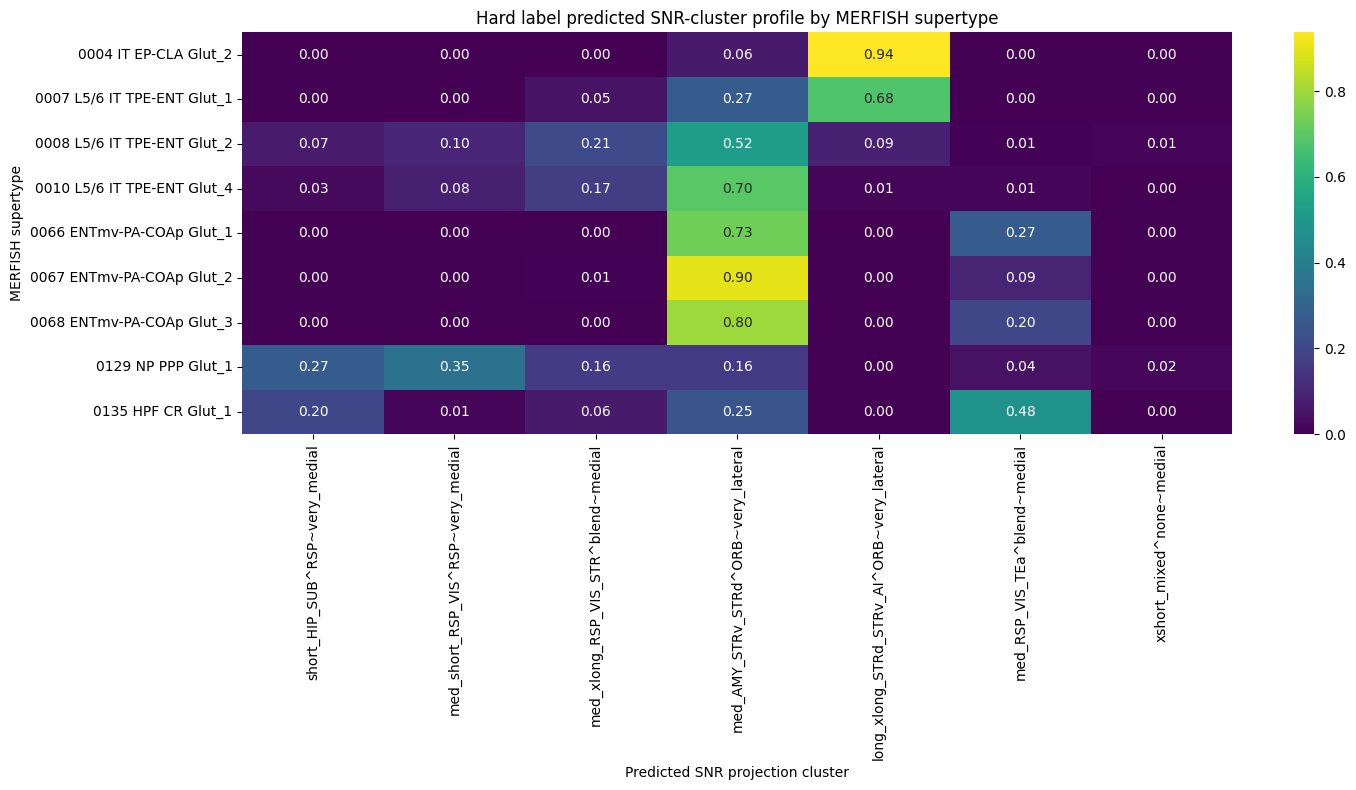

pred_cluster,short_HIP_SUB^RSP~very_medial,med_short_RSP_VIS^RSP~very_medial,med_xlong_RSP_VIS_STR^blend~medial,med_AMY_STRv_STRd^ORB~very_lateral,long_xlong_STRd_STRv_AI^ORB~very_lateral,med_RSP_VIS_TEa^blend~medial,xshort_mixed^none~medial
supertype,,,,,,,
0004 IT EP-CLA Glut_2,0.000000,0.000000,0.000000,0.063197,0.936803,0.000000,0.000000
0007 L5/6 IT TPE-ENT Glut_1,0.001340,0.000000,0.045576,0.270777,0.679625,0.000000,0.002681
0008 L5/6 IT TPE-ENT Glut_2,0.068129,0.098152,0.211316,0.518476,0.087760,0.005774,0.010393
0010 L5/6 IT TPE-ENT Glut_4,0.025063,0.081871,0.167084,0.695071,0.014202,0.013367,0.003342
0066 ENTmv-PA-COAp Glut_1,0.000000,0.000000,0.000000,0.730263,0.000000,0.269737,0.000000
0067 ENTmv-PA-COAp Glut_2,0.000000,0.002994,0.005988,0.898204,0.000000,0.092814,0.000000
0068 ENTmv-PA-COAp Glut_3,0.000000,0.000000,0.000000,0.799163,0.000000,0.200837,0.000000
0129 NP PPP Glut_1,0.267241,0.353448,0.163793,0.155172,0.000000,0.043103,0.017241
0135 HPF CR Glut_1,0.200000,0.012903,0.064516,0.245161,0.000000,0.477419,0.000000


In [16]:
df_st = analysis_df[
    analysis_df["supertype"].isin(supertype_filter)
].copy()

if isinstance(df_st["supertype"].dtype, pd.CategoricalDtype):
    df_st["supertype"] = df_st["supertype"].cat.remove_unused_categories()

df_st["pred_cluster"] = pd.Categorical(
    df_st["pred_cluster"],
    categories=cluster_order,
    ordered=True
)

hard_profile = pd.crosstab(
    df_st["supertype"],
    df_st["pred_cluster"],
    normalize="index",
    dropna=False
)

# Clean column names for display
profile_display = hard_profile.copy()
profile_display.columns = [c.replace("p_cluster__", "") for c in profile_display.columns]

# Reorder columns into desired cluster order
profile_display = profile_display.reindex(columns=cluster_order)

plt.figure(figsize=(15, 8))
sns.heatmap(hard_profile, annot=True, fmt=".2f", cmap="viridis")
plt.title("Hard label predicted SNR-cluster profile by MERFISH supertype")
plt.xlabel("Predicted SNR projection cluster")
plt.ylabel("MERFISH supertype")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(
    "Figures/fig_app_13_hard_labels.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()




hard_profile

/var/folders/c7/ytg8ypcn5cn63c0pfbjpj5yc0000gp/T/ipykernel_13199/3918602993.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("supertype")[cluster_prob_cols]


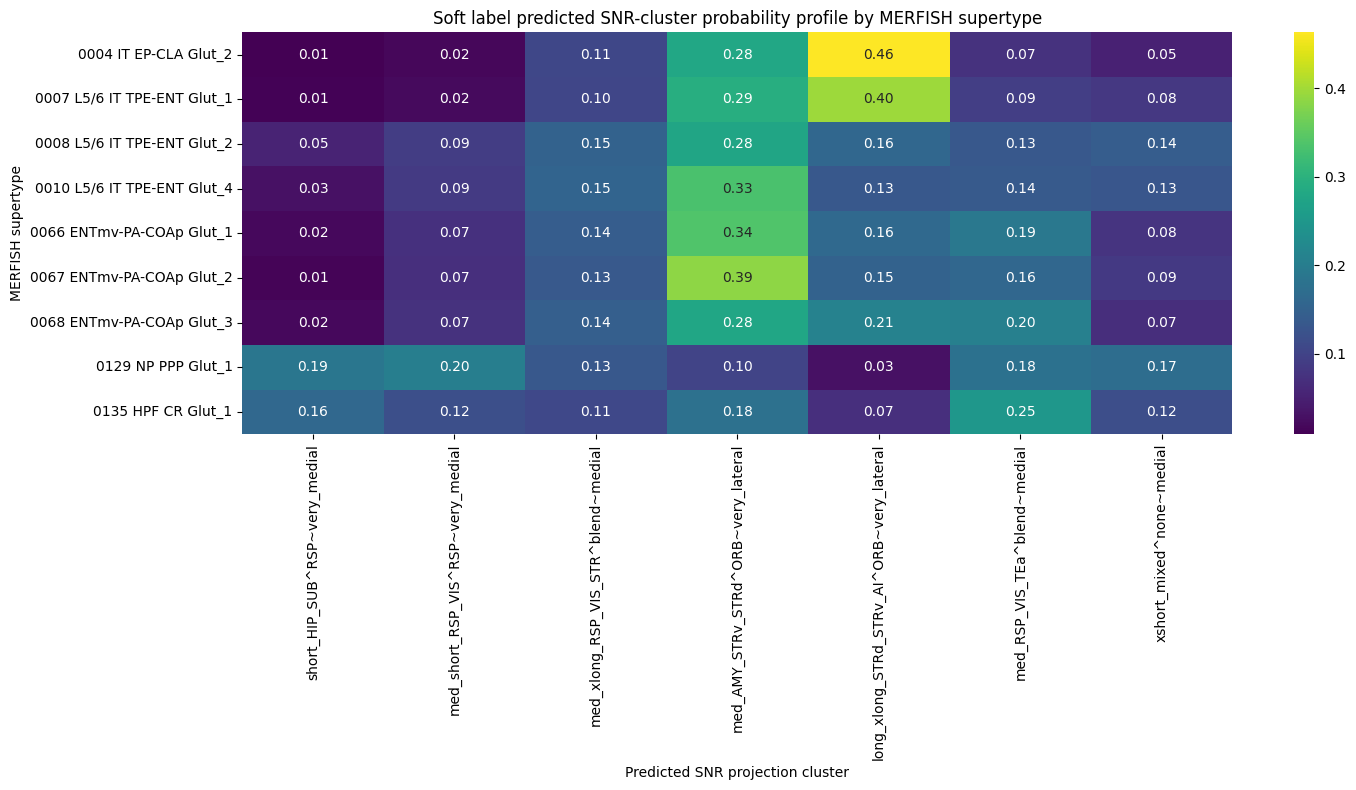

In [15]:
df_st = analysis_df[
    analysis_df["supertype"].isin(supertype_filter)
].copy()

# Remove unused categories if supertype is categorical
if isinstance(df_st["supertype"].dtype, pd.CategoricalDtype):
    df_st["supertype"] = df_st["supertype"].cat.remove_unused_categories()

profile = (
    df_st
    .groupby("supertype")[cluster_prob_cols]
    .mean()
)

# Clean column names for display
profile_display = profile.copy()
profile_display.columns = [c.replace("p_cluster__", "") for c in profile_display.columns]

# Reorder columns into desired cluster order
profile_display = profile_display.reindex(columns=cluster_order)

plt.figure(figsize=(15, 8))
sns.heatmap(profile_display, annot=True, fmt=".2f", cmap="viridis")
plt.title("Soft label predicted SNR-cluster probability profile by MERFISH supertype")
plt.xlabel("Predicted SNR projection cluster")
plt.ylabel("MERFISH supertype")
plt.tight_layout()
plt.savefig(
    "Figures/fig_app_14_soft_labels.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

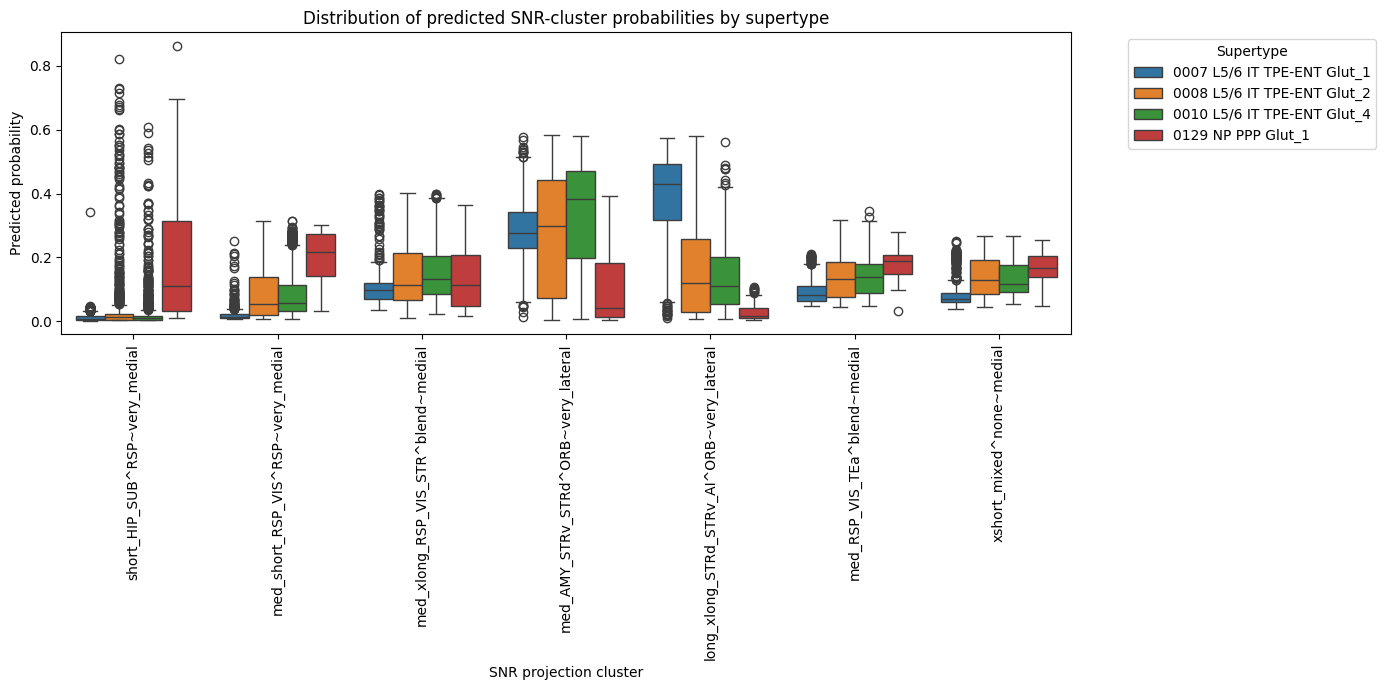

In [12]:
long_probs = df_st.melt(
    id_vars=[
        "supertype", "pred_cluster", "p_cluster_max",
        "cluster_entropy", "substructure", "structure"
    ],
    value_vars=cluster_prob_cols,
    var_name="cluster",
    value_name="probability"
)

# Clean probability column names so they match cluster_order
long_probs["cluster"] = long_probs["cluster"].str.replace("p_cluster__", "", regex=False)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=long_probs,
    x="cluster",
    y="probability",
    hue="supertype",
    order=cluster_order
)

plt.xticks(rotation=90)
plt.title("Distribution of predicted SNR-cluster probabilities by supertype")
plt.xlabel("SNR projection cluster")
plt.ylabel("Predicted probability")
plt.legend(title="Supertype", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

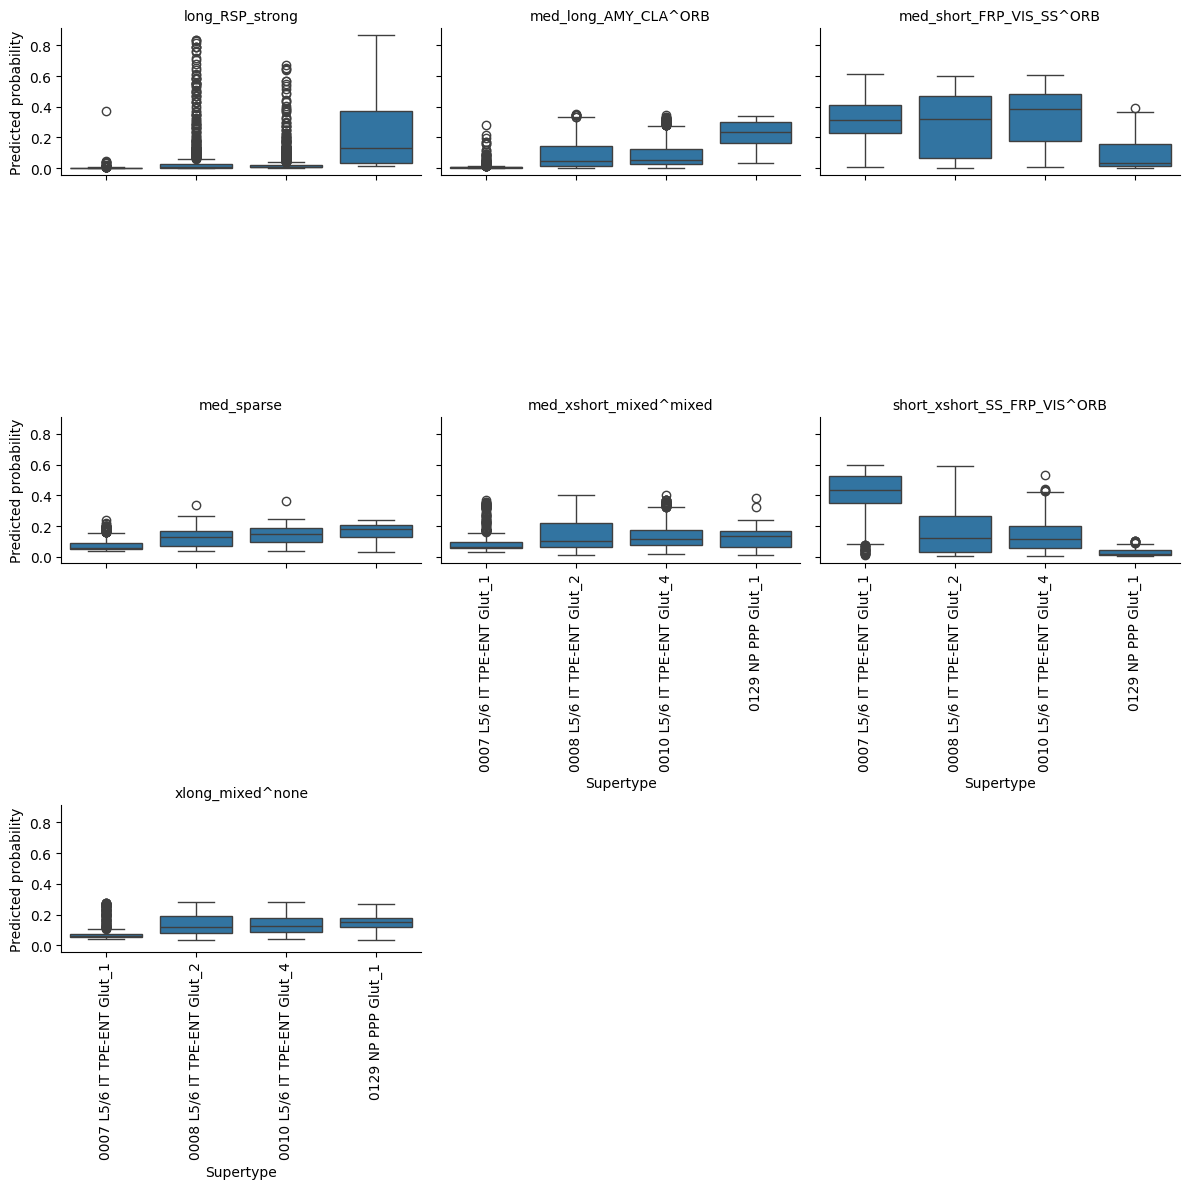

In [20]:
g = sns.FacetGrid(
    long_probs,
    col="cluster",
    col_wrap=3,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.boxplot,
    x="supertype",
    y="probability"
)

for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=90)

g.set_titles("{col_name}")
g.set_axis_labels("Supertype", "Predicted probability")
plt.tight_layout()
plt.show()

## Using supertype classifier probabilities

In [33]:
cluster_prob_cols = [f"cluster_prob_{c}" for c in cluster_names]
supertype_prob_cols = [f"supertype_prob_{s}" for s in supertype_names]

cluster_probs = cell_metadata[cluster_prob_cols].to_numpy()
supertype_probs = cell_metadata[supertype_prob_cols].to_numpy()

cluster_supertype_soft = cluster_probs.T @ supertype_probs

cluster_supertype_soft = pd.DataFrame(
    cluster_supertype_soft,
    index=cluster_names,
    columns=supertype_names
)

cluster_supertype_soft_norm = cluster_supertype_soft.div(
    cluster_supertype_soft.sum(axis=1),
    axis=0
)

cluster_supertype_soft_norm

,0007 L5/6 IT TPE-ENT Glut_1,0008 L5/6 IT TPE-ENT Glut_2,0010 L5/6 IT TPE-ENT Glut_4,0129 NP PPP Glut_1
med_long_RSP_VIS^RSP_mixed,0.277360,0.285267,0.334782,0.102591
med_long_STRv_STRd^ORB,0.289578,0.290431,0.373630,0.046361
med_xshort_^mixed,0.282329,0.277506,0.359085,0.081080
short_HIP_strong_SUB^RSP,0.210044,0.278755,0.272021,0.239180
short_med_long_RSP_VIS^RSP,0.193377,0.286991,0.347277,0.172354


In [34]:
cluster_supertype_soft = supertype_probs.T @ cluster_probs

cluster_supertype_soft = pd.DataFrame(
    cluster_supertype_soft,
    index=supertype_names,
    columns=cluster_names
)

cluster_supertype_soft_norm = cluster_supertype_soft.div(
    cluster_supertype_soft.sum(axis=1),
    axis=0
)

cluster_supertype_soft_norm

,med_long_RSP_VIS^RSP_mixed,med_long_STRv_STRd^ORB,med_xshort_^mixed,short_HIP_strong_SUB^RSP,short_med_long_RSP_VIS^RSP
0007 L5/6 IT TPE-ENT Glut_1,0.196635,0.338630,0.311712,0.074553,0.078471
0008 L5/6 IT TPE-ENT Glut_2,0.190138,0.319301,0.288050,0.093020,0.109490
0010 L5/6 IT TPE-ENT Glut_4,0.181430,0.333987,0.303055,0.073805,0.107723
0129 NP PPP Glut_1,0.195885,0.146012,0.241094,0.228643,0.188367


## Using MERFISH Supertype assignment

In [24]:
supertype_onehot = pd.get_dummies(cell_metadata["supertype"])

cluster_supertype_assigned = cluster_probs.T @ supertype_onehot.to_numpy()

cluster_supertype_assigned = pd.DataFrame(
    cluster_supertype_assigned,
    index=cluster_names,
    columns=supertype_onehot.columns
)

cluster_supertype_assigned_norm = cluster_supertype_assigned.div(
    cluster_supertype_assigned.sum(axis=1),
    axis=0
)

cluster_supertype_assigned_norm

,0001 CLA-EPd-CTX Car3 Glut_1,0002 CLA-EPd-CTX Car3 Glut_2,0003 IT EP-CLA Glut_1,0004 IT EP-CLA Glut_2,0007 L5/6 IT TPE-ENT Glut_1,0008 L5/6 IT TPE-ENT Glut_2,0010 L5/6 IT TPE-ENT Glut_4,0011 L5/6 IT TPE-ENT Glut_5,0012 L5/6 IT TPE-ENT Glut_6,0013 L6 IT CTX Glut_1,...,0264 OT D3 Folh1 Gaba_3,0285 STR-PAL Chst9 Gaba_1,0290 IA Mgp Gaba_1,0291 IA Mgp Gaba_2,0355 MEA-BST Lhx6 Nr2e1 Gaba_2,0356 MEA-BST Lhx6 Nr2e1 Gaba_3,0380 CEA-AAA-BST Six3 Sp9 Gaba_8,0510 COAa-PAA-MEA Barhl2 Glut_2,0512 COAa-PAA-MEA Barhl2 Glut_4,0514 COAa-PAA-MEA Barhl2 Glut_6
med_long_RSP_VIS^RSP_mixed,0.001106,0.000087,0.001204,0.003736,0.011337,0.017296,0.020424,0.000040,0.000025,0.000234,...,0.000021,0.000036,0.000014,0.000027,0.000089,0.000015,0.000021,0.000020,0.000310,0.000686
med_long_STRv_STRd^ORB,0.002465,0.000151,0.003117,0.010716,0.026649,0.021689,0.033238,0.000040,0.000004,0.000035,...,0.000010,0.000081,0.000017,0.000062,0.000129,0.000034,0.000022,0.000022,0.000820,0.001059
med_xshort_^mixed,0.001167,0.000091,0.000984,0.003369,0.011961,0.016952,0.024990,0.000022,0.000019,0.000149,...,0.000034,0.000020,0.000033,0.000042,0.000109,0.000018,0.000022,0.000022,0.000329,0.000885
short_HIP_strong_SUB^RSP,0.000849,0.000066,0.000716,0.002673,0.007050,0.011463,0.010159,0.000136,0.000005,0.000138,...,0.000018,0.000018,0.000014,0.000022,0.000071,0.000011,0.000016,0.000016,0.000222,0.000528
short_med_long_RSP_VIS^RSP,0.000708,0.000058,0.000599,0.002128,0.006237,0.015447,0.018776,0.000015,0.000078,0.000483,...,0.000017,0.000014,0.000013,0.000019,0.000062,0.000009,0.000015,0.000015,0.000181,0.000469
